In [11]:
import warnings
warnings.filterwarnings("ignore")

import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from textblob import TextBlob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    DistilBertTokenizer,
    DistilBertModel,
    DistilBertForSequenceClassification
)

nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")

[nltk_data] Downloading package punkt to C:\Users\Ananjay
[nltk_data]     Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ananjay Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [12]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to C:\Users\Ananjay
[nltk_data]     Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Ananjay
[nltk_data]     Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ananjay Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Ananjay Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [13]:
# =========================
# LOAD ISOT DATASET
# =========================

fake_df = pd.read_csv("../data/ISOT/Fake.csv")
true_df = pd.read_csv("../data/ISOT/True.csv")

# Labels
fake_df["label"] = 0
true_df["label"] = 1

# Combine title + text
fake_df["text"] = fake_df["title"] + " " + fake_df["text"]
true_df["text"] = true_df["title"] + " " + true_df["text"]

# Keep only required columns
fake_df = fake_df[["text", "label"]]
true_df = true_df[["text", "label"]]

# Combine
isot_df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

print(isot_df.shape)
isot_df.head()

(44898, 2)


,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0


In [14]:
# Reduce dataset size for faster CPU training

isot_df = isot_df.sample(
    12000,
    random_state=42
).reset_index(drop=True)

print(isot_df.shape)

(12000, 2)


In [15]:
OUTPUT_DIR = Path("../outputs")

train_df = pd.read_csv(OUTPUT_DIR / "train_processed.csv")
test_df  = pd.read_csv(OUTPUT_DIR / "test_processed.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(10232, 2) (2559, 2)


,text,label
0,in the last two years super pacs raised more t...,1
1,80 percent of the american people havent gotte...,1
2,big rooftop solars plan forces nevada families...,1
3,ann kuster turned a blind eye to those in need...,0
4,liberals have figured out a facebook algorithm...,0


In [16]:
# =========================
# COMBINE LIAR + ISOT
# =========================

liar_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

combined_df = pd.concat(
    [liar_df, isot_df],
    ignore_index=True
)

combined_df = combined_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(combined_df.shape)

combined_df.head()

(24791, 2)


,text,label
0,georgias illegal immigration crackdown laws sh...,0
1,170000 of the jobs created in texas under gov ...,1
2,U.S. State Dept keeps hiring freeze as Tillers...,1
3,Scooby Doo’s ‘Mystery Machine’ Involved In Cr...,0
4,"'We appoint our ambassadors', says UK PM's spo...",1


In [17]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    combined_df["text"],
    combined_df["label"],
    test_size=0.2,
    random_state=42
)

print(len(train_texts), len(test_texts))

19832 4959


In [18]:
def pos_ratio(text):
    tokens = nltk.word_tokenize(text)
    tags = nltk.pos_tag(tokens)

    adj = sum(1 for _, tag in tags if tag.startswith("JJ"))
    noun = sum(1 for _, tag in tags if tag.startswith("NN"))

    return adj / (noun + 1)

def sentiment_score(text):
    return TextBlob(text).sentiment.polarity

In [19]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)

# POS Ratio
train_pos = pd.Series(train_texts).apply(pos_ratio).values.reshape(-1,1)
test_pos  = pd.Series(test_texts).apply(pos_ratio).values.reshape(-1,1)

# Sentiment
train_sent = pd.Series(train_texts).apply(sentiment_score).values.reshape(-1,1)
test_sent  = pd.Series(test_texts).apply(sentiment_score).values.reshape(-1,1)

from scipy.sparse import hstack

X_train_classical = hstack([X_train_tfidf, train_pos, train_sent])
X_test_classical  = hstack([X_test_tfidf, test_pos, test_sent])

y_train = train_labels
y_test  = test_labels

In [20]:
classical_clf = LogisticRegression(max_iter=1000)
classical_clf.fit(X_train_classical, y_train)

classical_preds = classical_clf.predict(X_test_classical)

print("CLASSICAL NLP RESULTS")
print(classification_report(y_test, classical_preds))

CLASSICAL NLP RESULTS
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      2397
           1       0.78      0.82      0.80      2562

    accuracy                           0.78      4959
   macro avg       0.78      0.78      0.78      4959
weighted avg       0.78      0.78      0.78      4959



In [21]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [22]:
class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [23]:
train_dataset = BertDataset(
    train_texts,
    train_labels,
    tokenizer
)

test_dataset = BertDataset(
    test_texts,
    test_labels,
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from transformers import DistilBertForSequenceClassification

bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

optimizer = torch.optim.AdamW(
    bert_model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
def train_bert(model, loader, epochs=3):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1} Loss: {total_loss / len(loader):.4f}")

In [26]:
import gc
gc.collect()

torch.cuda.empty_cache()
train_bert(bert_model, train_loader)

100%|██████████| 4958/4958 [36:53<00:00,  2.24it/s]


Epoch 1 Loss: 0.3534


100%|██████████| 4958/4958 [39:41<00:00,  2.08it/s]


Epoch 2 Loss: 0.3070


100%|██████████| 4958/4958 [40:29<00:00,  2.04it/s]

Epoch 3 Loss: 0.2103


In [27]:
def evaluate_bert(model, loader):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    return preds, labels_all

bert_preds, bert_true = evaluate_bert(bert_model, test_loader)

print("BERT RESULTS")
print(classification_report(bert_true, bert_preds))

BERT RESULTS
              precision    recall  f1-score   support

           0       0.81      0.78      0.79      2397
           1       0.80      0.83      0.81      2562

    accuracy                           0.80      4959
   macro avg       0.80      0.80      0.80      4959
weighted avg       0.80      0.80      0.80      4959



In [28]:
from transformers import DistilBertModel

bert_encoder = DistilBertModel.from_pretrained(
    "distilbert-base-uncased"
).to(device)

bert_encoder.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [29]:
def extract_cls_embeddings(texts, batch_size=16):
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts.iloc[i:i+batch_size].tolist()

        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = bert_encoder(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device)
            )

        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)

    return np.vstack(embeddings)

In [30]:
X_train_bert = extract_cls_embeddings(pd.Series(train_texts))
X_test_bert  = extract_cls_embeddings(pd.Series(test_texts))

X_train_hybrid = np.hstack([X_train_bert, train_pos, train_sent])
X_test_hybrid  = np.hstack([X_test_bert, test_pos, test_sent])

100%|██████████| 310/310 [02:55<00:00,  1.76it/s]


In [31]:
hybrid_clf = LogisticRegression(max_iter=1000)
hybrid_clf.fit(X_train_hybrid, y_train)

hybrid_preds = hybrid_clf.predict(X_test_hybrid)

print("HYBRID RESULTS")
print(classification_report(y_test, hybrid_preds))

HYBRID RESULTS
              precision    recall  f1-score   support

           0       0.79      0.76      0.77      2397
           1       0.78      0.81      0.80      2562

    accuracy                           0.79      4959
   macro avg       0.79      0.79      0.79      4959
weighted avg       0.79      0.79      0.79      4959



In [32]:
classical_f1 = f1_score(y_test, classical_preds)
bert_f1 = f1_score(bert_true, bert_preds)
hybrid_f1 = f1_score(y_test, hybrid_preds)

results = pd.DataFrame({
    "Model": ["Classical NLP", "BERT", "Hybrid"],
    "F1 Score": [classical_f1, bert_f1, hybrid_f1]
})

results

,Model,F1 Score
0,Classical NLP,0.795359
1,BERT,0.812715
2,Hybrid,0.797321


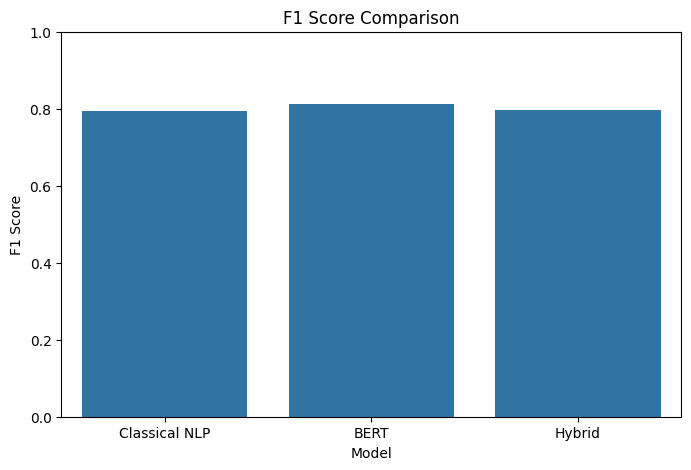

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="F1 Score")
plt.title("F1 Score Comparison")
plt.ylim(0,1)
plt.show()

In [34]:
errors = pd.DataFrame({
    "text": test_texts.values,
    "true": y_test.values,
    "pred": hybrid_preds
})

misclassified = errors[errors["true"] != errors["pred"]].head(20)
misclassified

,text,true,pred
6,gun homicide is down 49 percent in the past 12...,0,1
36,president barack obamas policies have forced m...,0,1
38,obamacare will provide coverage for abortions ...,1,0
45,says al franken voted to exempt himself and co...,0,1
48,donald trump says that nato is obsolete and th...,0,1
59,says sen robert cowles her recall opponent sup...,0,1
64,says florida gov rick scotts cuts to education...,0,1
67,one of george soros companies has provided som...,0,1
68,louie gohmert of texas compared the current ge...,1,0
80,says unlike tim kaine who investedin education...,0,1


In [35]:
misclassified.to_csv("../outputs/misclassified_20.csv", index=False)
print("Saved to outputs/misclassified_20.csv")

Saved to outputs/misclassified_20.csv


In [36]:
bert_model.save_pretrained("../models/bert_model")
tokenizer.save_pretrained("../models/bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/bert_model\\tokenizer_config.json',
 '../models/bert_model\\tokenizer.json')

In [37]:
import joblib

joblib.dump(hybrid_clf, "../models/hybrid_clf.pkl")
joblib.dump(tfidf, "../models/tfidf.pkl")

['../models/tfidf.pkl']

In [38]:
bert_model.save_pretrained("../models/fake_news_model")
tokenizer.save_pretrained("../models/fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/fake_news_model\\tokenizer_config.json',
 '../models/fake_news_model\\tokenizer.json')